# Intrinsic Time-Scale Decomposition (ITD)

**ITD** (Frei & Osorio, 2007) peels a non-stationary record into
**proper rotation components (PRCs)** plus a residual *baseline*.  Unlike EMD
it never builds cubic-spline envelopes: between consecutive extrema the
baseline is a **piecewise-linear function of the signal value itself**, so
each step is $O(N)$ and suitable for real-time filtering.

$$
x(t)=\sum_{k=1}^{K} H_k(t)+L_K(t),
$$

where $H_k=x_k-L_k$ is a PRC (a single rotation in the Hilbert plane) and
$L_K$ is the monotonic / low-energy residual.

PySDKit `ITD` follows the MATLAB File Exchange port (`repo/itd.m`,
Linshan Jia, XJTU) of the Frei–Osorio construction: $\alpha=0.5$ control
points, linear interpolation of the opposite envelope, and the same three
stop tests.

| | **EMD** | **ITD** (this notebook) |
|---|---|---|
| Local mean | cubic spline of extrema | linear baseline $L_t$ between extrema |
| Modes | IMFs (sifted until symmetry) | PRCs (one baseline extract per mode) |
| Inner loop | many sifts per IMF | **none** — one pass per PRC |
| Cost | spline + repeated sifts | $O(N)$ per iteration |

**References**

> M. G. Frei and I. Osorio.
> *Intrinsic time-scale decomposition: time-frequency-energy analysis and real-time filtering of non-stationary signals.*
> Proc. R. Soc. A **463**, 321–342 (2007).
> https://doi.org/10.1098/rspa.2006.1761

MATLAB: [File Exchange 69380](https://www.mathworks.com/matlabcentral/fileexchange/69380-intrinsic-time-scale-decomposition-itd)
(`repo/itd.m`).


## 1. Algorithm (matching `itd.m`)

### 1.1 Baseline extract (`itd_baseline_extract`)

1. Locate maxima $\{t_k^+, x_k^+\}$ and minima $\{t_k^-, x_k^-\}$
   (`findpeaks` / `scipy.signal.find_peaks`).
2. Pad the shorter side so both sets span the same index range (MATLAB
   boundary block).
3. Linearly interpolate the upper and lower envelopes on the full grid.
4. Control points with $\alpha=0.5$:

$$
L(t_k^-)=\alpha\,\widehat{x}_{\max}(t_k^-)+(1-\alpha)\,x(t_k^-),
\qquad
L(t_k^+)=\alpha\,\widehat{x}_{\min}(t_k^+)+(1-\alpha)\,x(t_k^+).
$$

5. Between successive extrema $t_i,t_{i+1}$ the baseline is **linear in
   the signal**, not in time (Frei & Osorio; MATLAB inner loop):

$$
\kappa_i=\frac{L_{i+1}-L_i}{x(t_{i+1})-x(t_i)},
\qquad
L(t)=L_i+\kappa_i\bigl(x(t)-x(t_i)\bigr),\quad t\in[t_i,t_{i+1}).
$$

6. The PRC is $H(t)=x(t)-L(t)$.  Replace $x\leftarrow L$ and repeat.

### 1.2 Stop tests (`stop_iter`)

Iteration ends when **any** of the following holds (same as MATLAB):

| Test | Condition |
|---|---|
| Iteration cap | `counter > N_max` (default 10) |
| Residual energy | $\sum L^2 \le 0.01\sum x^2$ |
| Too few extrema | $\#\{\text{maxima}\cup\text{minima}\}\le 7$ |

The last baseline $L$ is appended as the residue row.  Summing all rows
recovers $x$ (up to rounding).


## 2. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, hilbert

from pysdkit import ITD, EMD
from pysdkit.data import test_emd, test_univariate_signal, test_hht
from pysdkit.plot import plot_IMFs

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(ITD())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Intrinsic Time-Scale Decomposition (ITD)


## 3. One baseline step

A single call to `itd_baseline_extract` is the whole “sift”.  The figure
below shows extrema, the linear envelopes used to build $L_k$, the
baseline $L$, and the first PRC $H=x-L$.


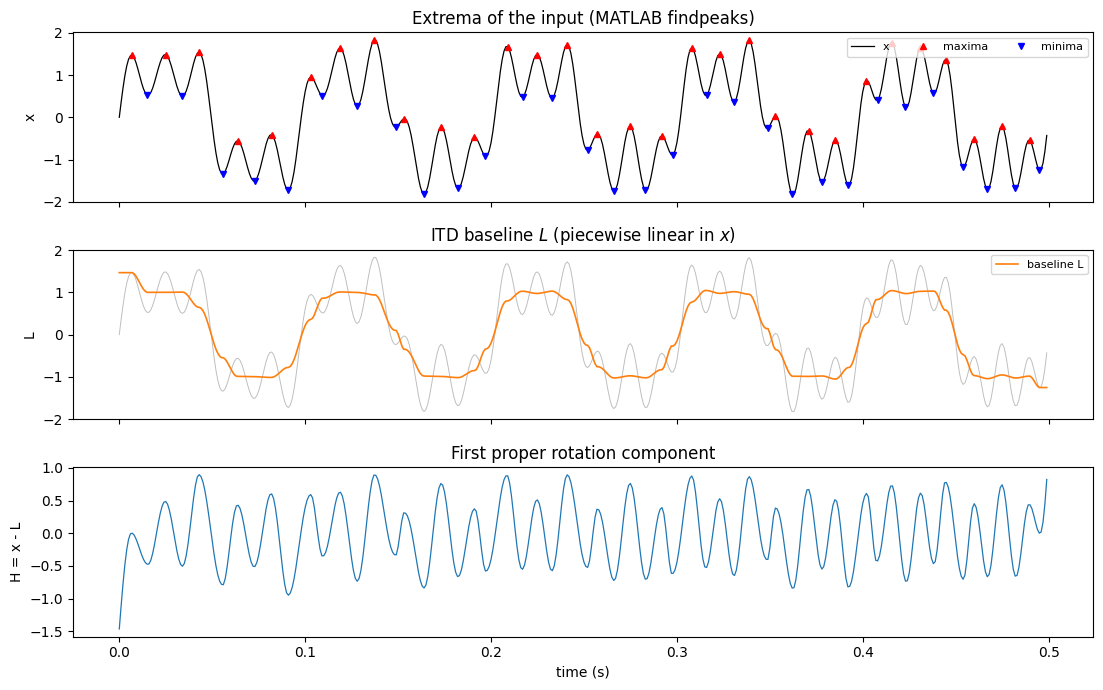

energy(H) / energy(x) = 0.204612390496682
max |x - (L+H)| = 1.1102230246251565e-16


In [2]:
t, x = test_univariate_signal(case=1, duration=0.5, sampling_rate=1000)
L, H = ITD.itd_baseline_extract(x)

idx_max, _ = find_peaks(x)
idx_min, _ = find_peaks(-x)

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].plot(t, x, color="k", lw=0.9, label="x")
axes[0].plot(t[idx_max], x[idx_max], "r^", ms=5, label="maxima")
axes[0].plot(t[idx_min], x[idx_min], "bv", ms=5, label="minima")
axes[0].set_ylabel("x")
axes[0].legend(loc="upper right", ncol=3, fontsize=8)
axes[0].set_title("Extrema of the input (MATLAB findpeaks)")

axes[1].plot(t, x, color="0.75", lw=0.7)
axes[1].plot(t, L, color="C1", lw=1.2, label="baseline L")
axes[1].set_ylabel("L")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_title(r"ITD baseline $L$ (piecewise linear in $x$)")

axes[2].plot(t, H, color="C0", lw=0.9)
axes[2].set_ylabel("H = x - L")
axes[2].set_xlabel("time (s)")
axes[2].set_title("First proper rotation component")
plt.tight_layout()
plt.show()

print("energy(H) / energy(x) =", np.sum(H**2) / np.sum(x**2))
print("max |x - (L+H)| =", np.max(np.abs(x - (L + H))))

## 4. Full decomposition of a three-tone AM–FM mixture

`test_univariate_signal(case=1)` is a 10 Hz sine, a 30 Hz sine and a
quadratic chirp — a typical ITD / EMD demo.  Rows of `fit_transform` are
PRCs; the **last row is the residue**.


signal (1000,) PRCs+residue (5, 1000)
reconstruction max |error| 2.220446049250313e-16


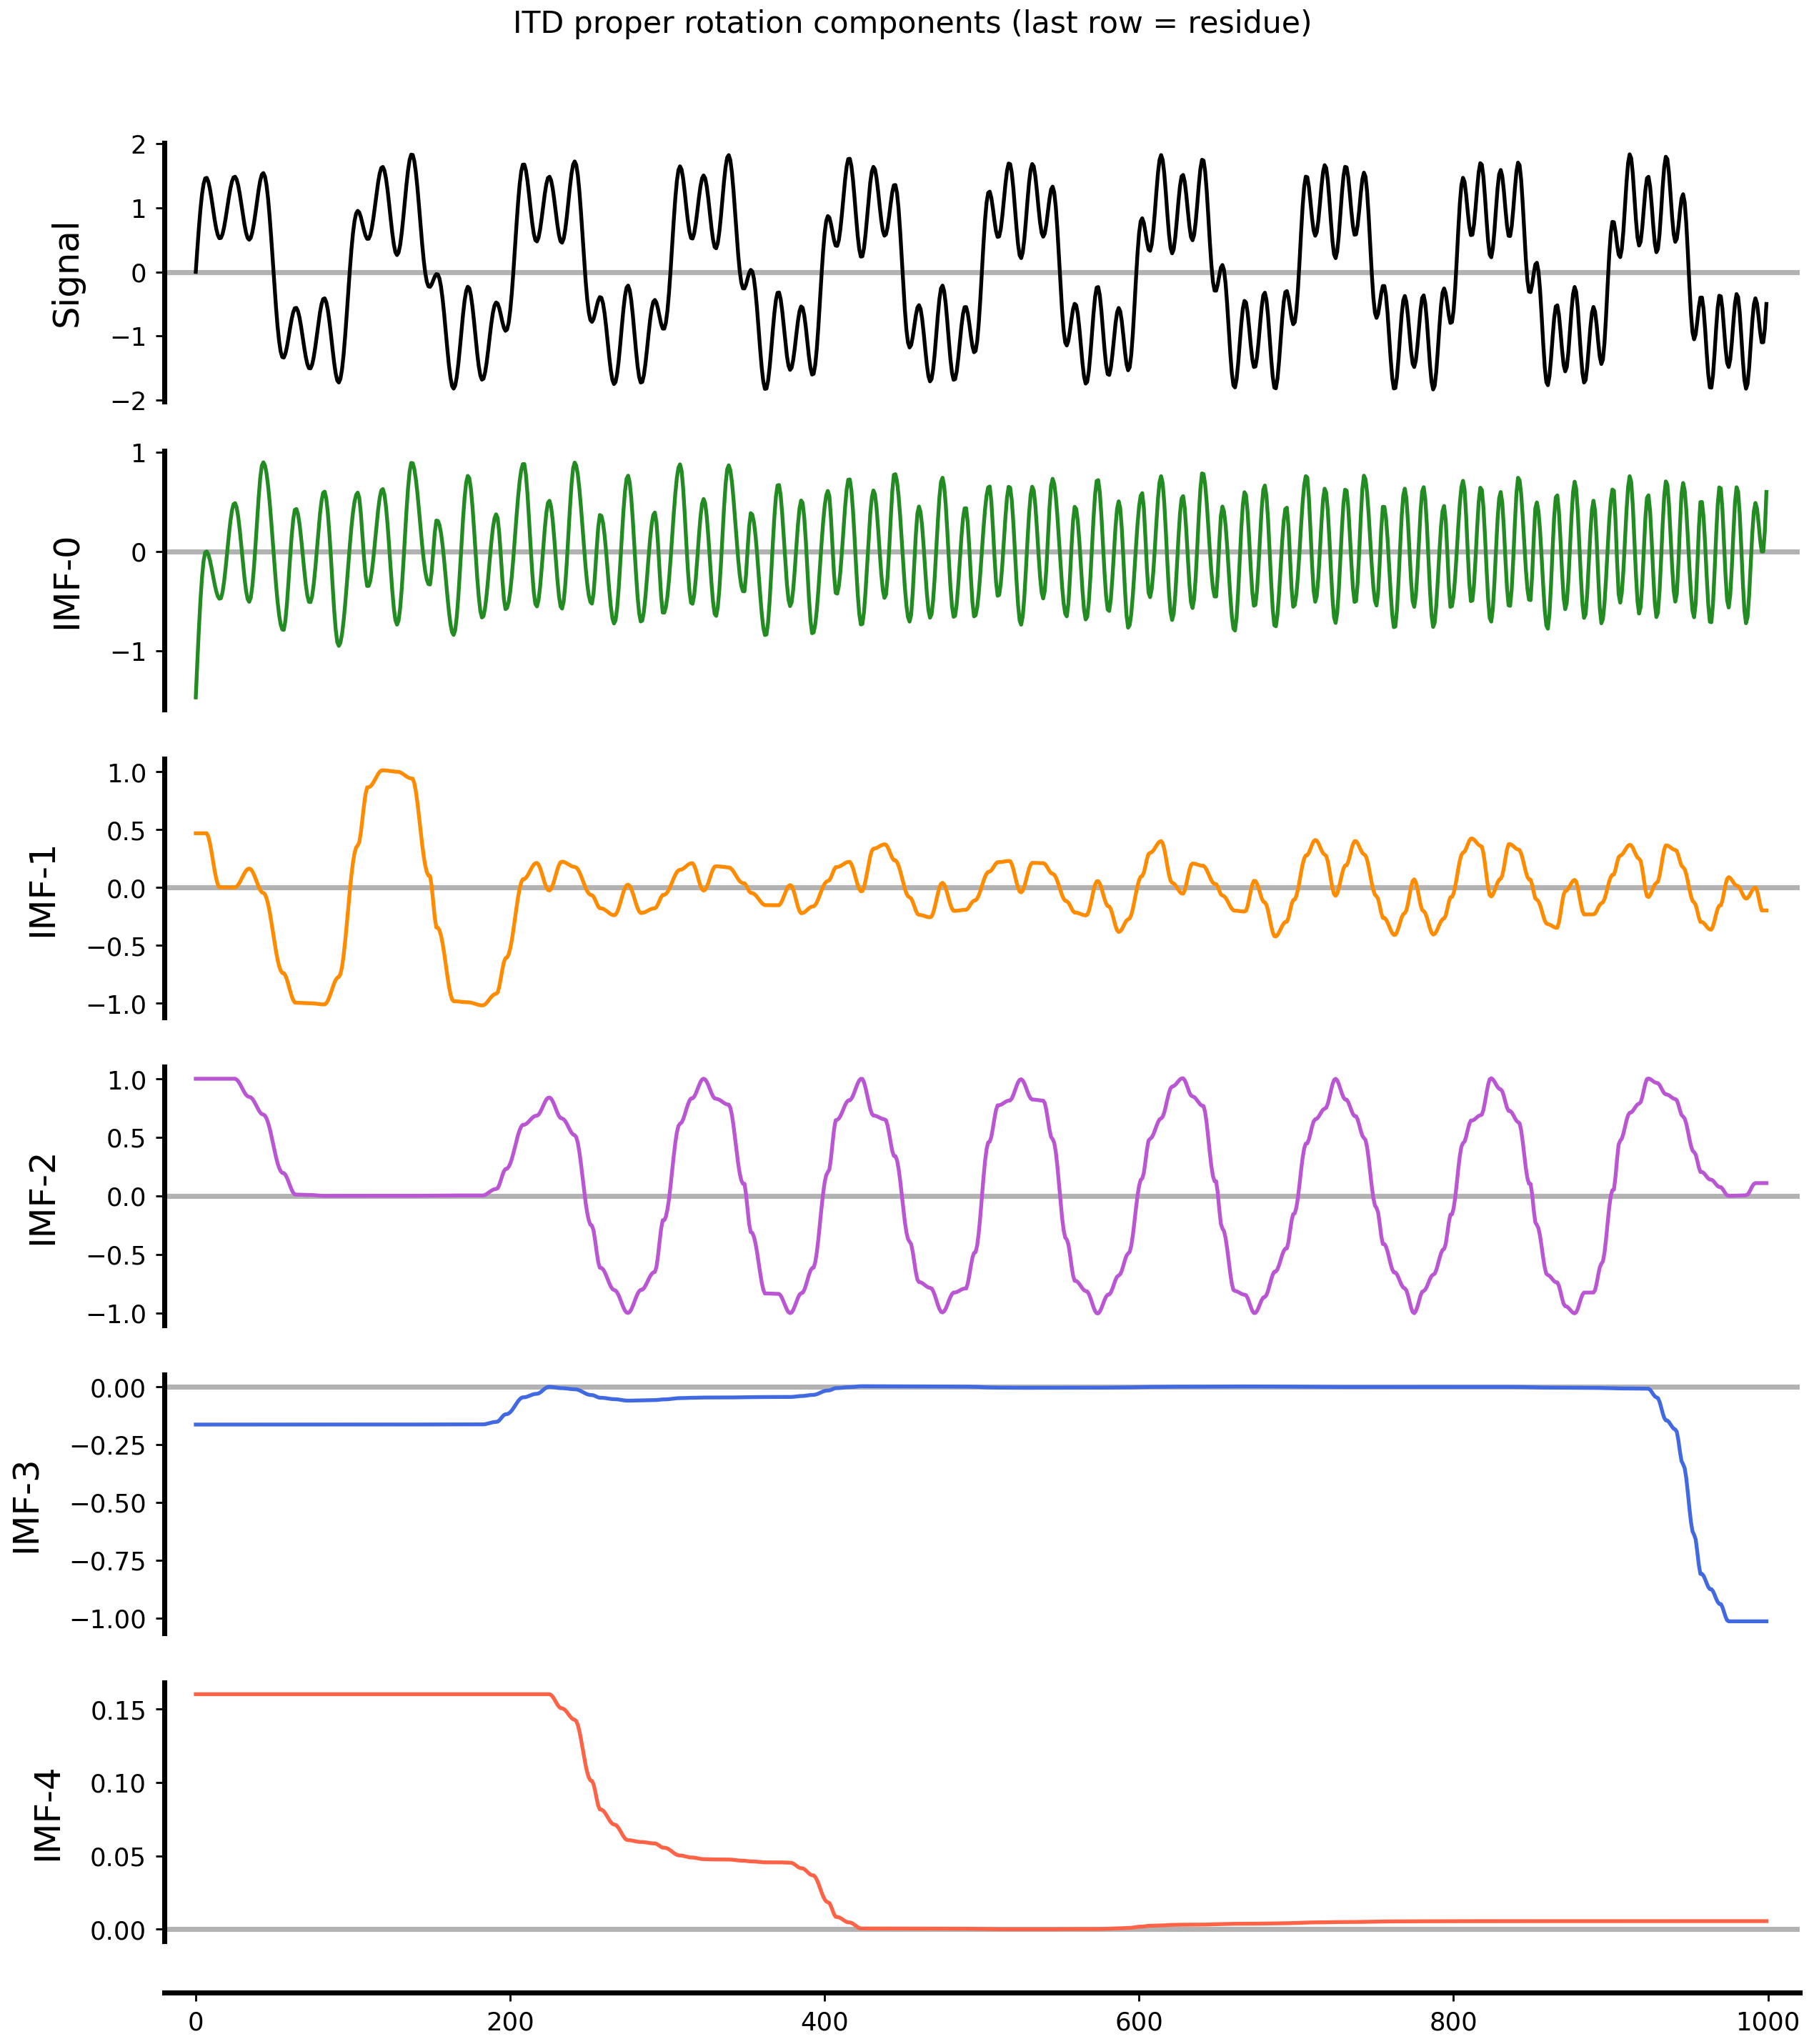

In [3]:
t, signal = test_univariate_signal(case=1)
itd = ITD(N_max=10)
prcs = itd.fit_transform(signal)

print("signal", signal.shape, "PRCs+residue", prcs.shape)
print("reconstruction max |error|", np.max(np.abs(prcs.sum(axis=0) - signal)))

fig = plot_IMFs(signal, prcs, return_figure=True)
fig.suptitle("ITD proper rotation components (last row = residue)", y=1.02)
plt.tight_layout()
plt.show()

### 4.1 Instantaneous amplitude and frequency

Frei & Osorio designed PRCs so that the Hilbert transform of each $H_k$
is a well-defined rotation (no spline overshoot).  The plots below are
the analytic-signal amplitude and a smoothed instantaneous frequency for
the first few PRCs.


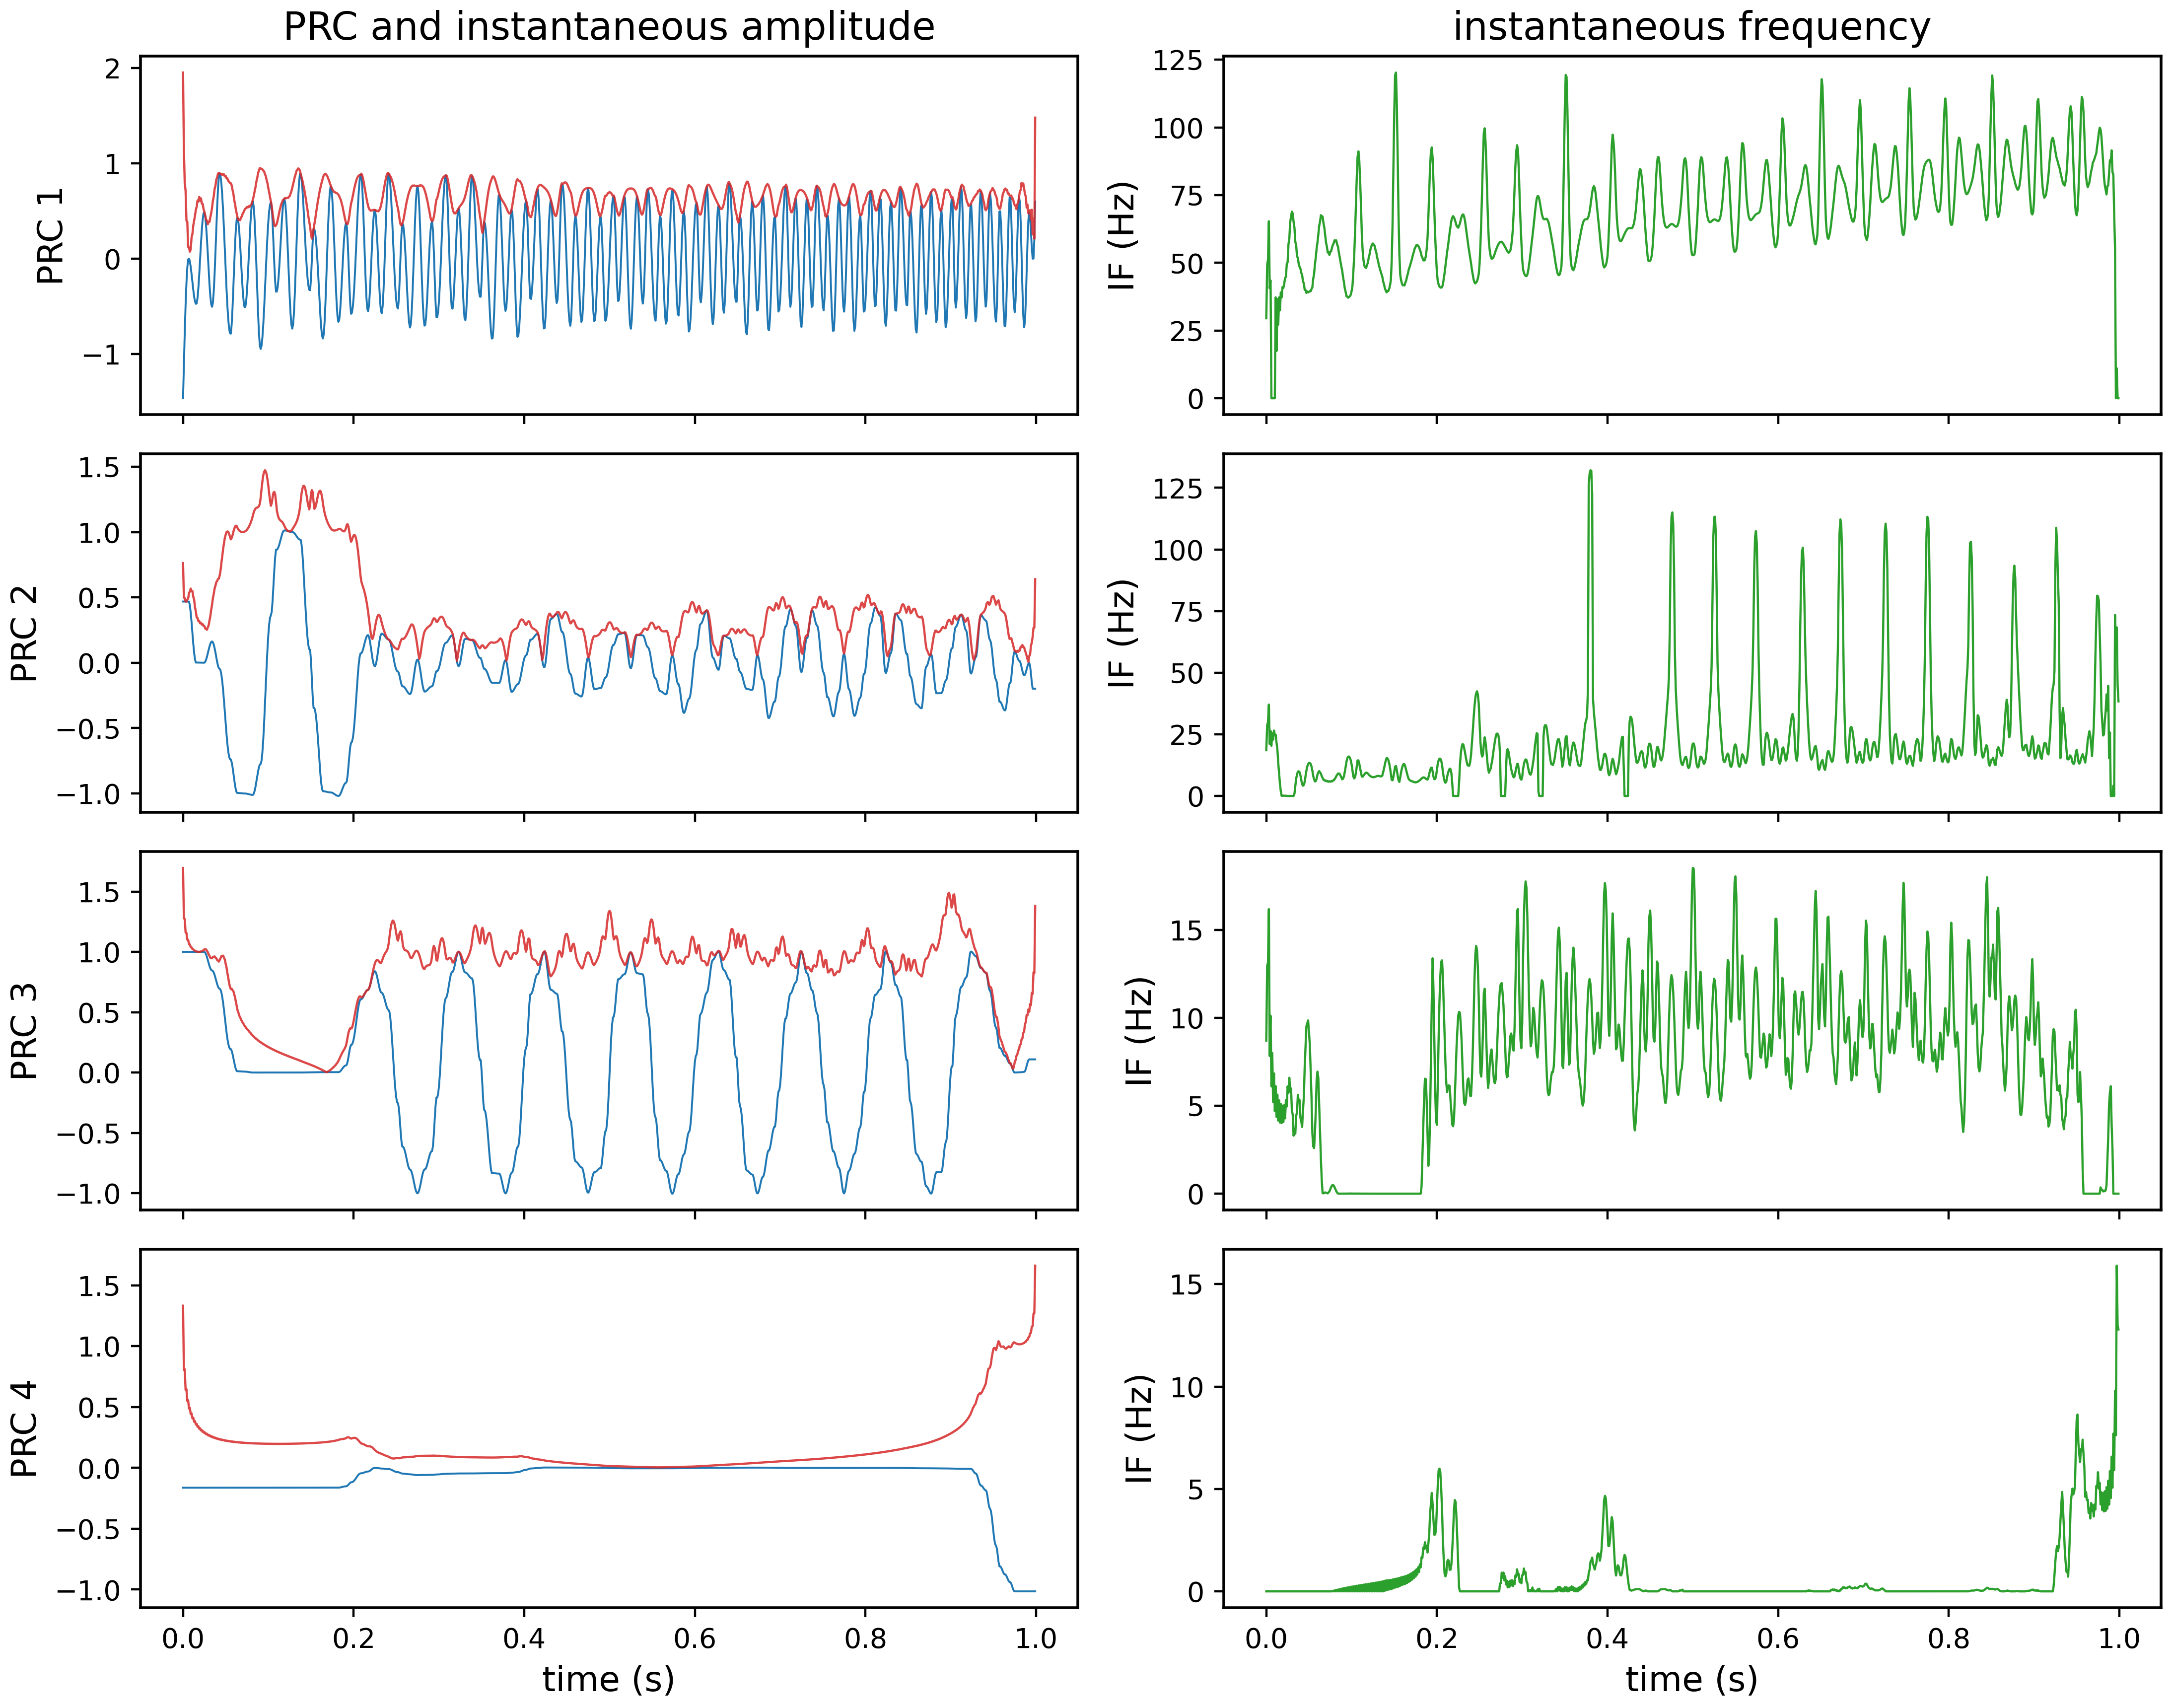

In [4]:
def inst_freq(mode: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray]:
    z = hilbert(mode)
    amp = np.abs(z)
    phase = np.unwrap(np.angle(z))
    freq = np.diff(phase, prepend=phase[0]) * fs / (2.0 * np.pi)
    # 5-sample moving average to tame end spikes
    kernel = np.ones(5) / 5.0
    freq_s = np.convolve(freq, kernel, mode="same")
    return amp, freq_s


fs = 1.0 / (t[1] - t[0])
n_show = min(4, prcs.shape[0] - 1)
fig, axes = plt.subplots(n_show, 2, figsize=(11, 2.2 * n_show), sharex=True)
if n_show == 1:
    axes = np.array([axes])
for k in range(n_show):
    amp, freq = inst_freq(prcs[k], fs)
    axes[k, 0].plot(t, prcs[k], color="C0", lw=0.7)
    axes[k, 0].plot(t, amp, color="C3", lw=0.8, alpha=0.85)
    axes[k, 0].set_ylabel(f"PRC {k + 1}")
    axes[k, 1].plot(t, np.clip(freq, 0, fs / 2), color="C2", lw=0.8)
    axes[k, 1].set_ylabel("IF (Hz)")
axes[0, 0].set_title("PRC and instantaneous amplitude")
axes[0, 1].set_title("instantaneous frequency")
axes[-1, 0].set_xlabel("time (s)")
axes[-1, 1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

## 5. Chirp plus quadratic trend (`test_emd`)

The built-in EMD demo $\cos(22\pi t^2)+2t^2$ plus light noise mixes a
sweeping oscillation with a slow baseline — exactly the setting ITD was
written for (trend in $L_K$, rotation in $H_1$).


test_emd PRCs (6, 1000) recon 4.440892098500626e-16


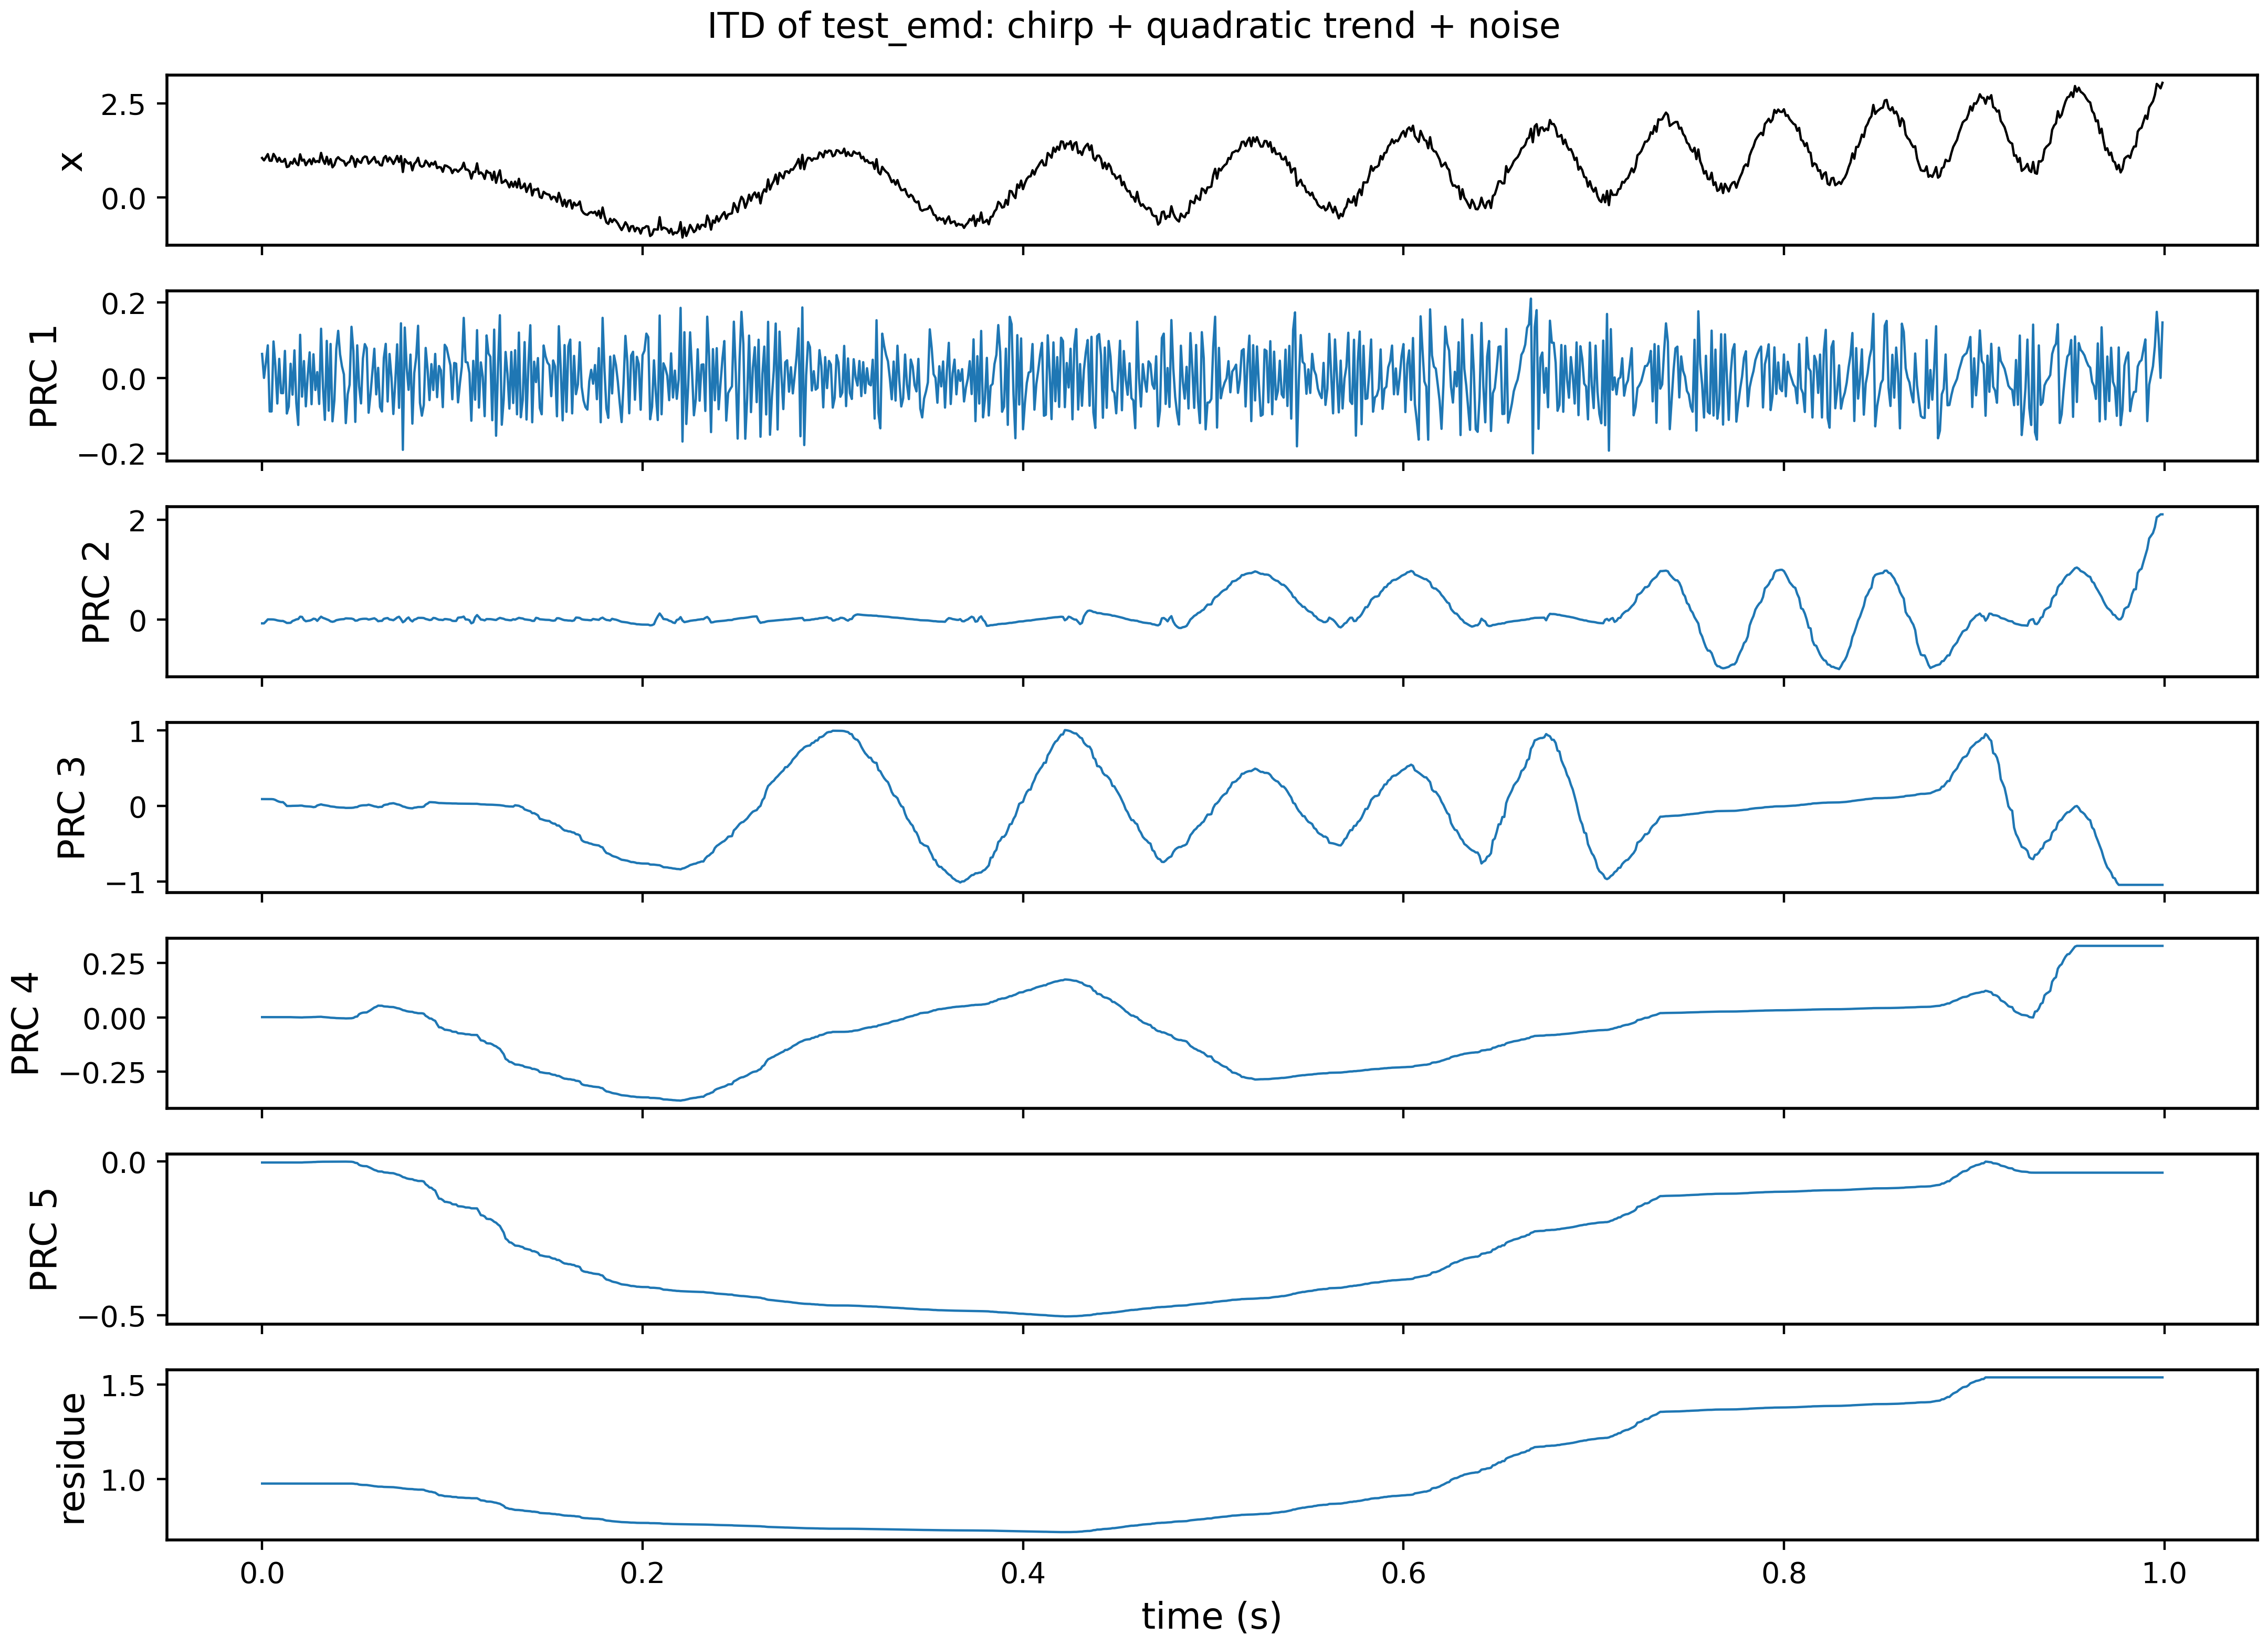

In [5]:
t2, x2 = test_emd()
prcs2 = ITD(N_max=8).fit_transform(x2)
print("test_emd PRCs", prcs2.shape, "recon", np.max(np.abs(prcs2.sum(0) - x2)))

fig, axes = plt.subplots(
    prcs2.shape[0] + 1, 1, figsize=(11, 1.15 * (prcs2.shape[0] + 1)), sharex=True
)
axes[0].plot(t2, x2, color="k", lw=0.8)
axes[0].set_ylabel("x")
for k in range(prcs2.shape[0]):
    axes[k + 1].plot(t2, prcs2[k], lw=0.8)
    ylab = "residue" if k == prcs2.shape[0] - 1 else f"PRC {k + 1}"
    axes[k + 1].set_ylabel(ylab)
axes[-1].set_xlabel("time (s)")
fig.suptitle("ITD of test_emd: chirp + quadratic trend + noise")
plt.tight_layout()
plt.show()

## 6. Real-time style filtering: keep selected PRCs

Because each PRC is obtained in one $O(N)$ pass, ITD is often used as an
on-line filter: discard the highest-frequency rotation (noise-like) or
keep only the residue (detrend).  The next cell low-passes `test_hht` by
dropping PRC 1.


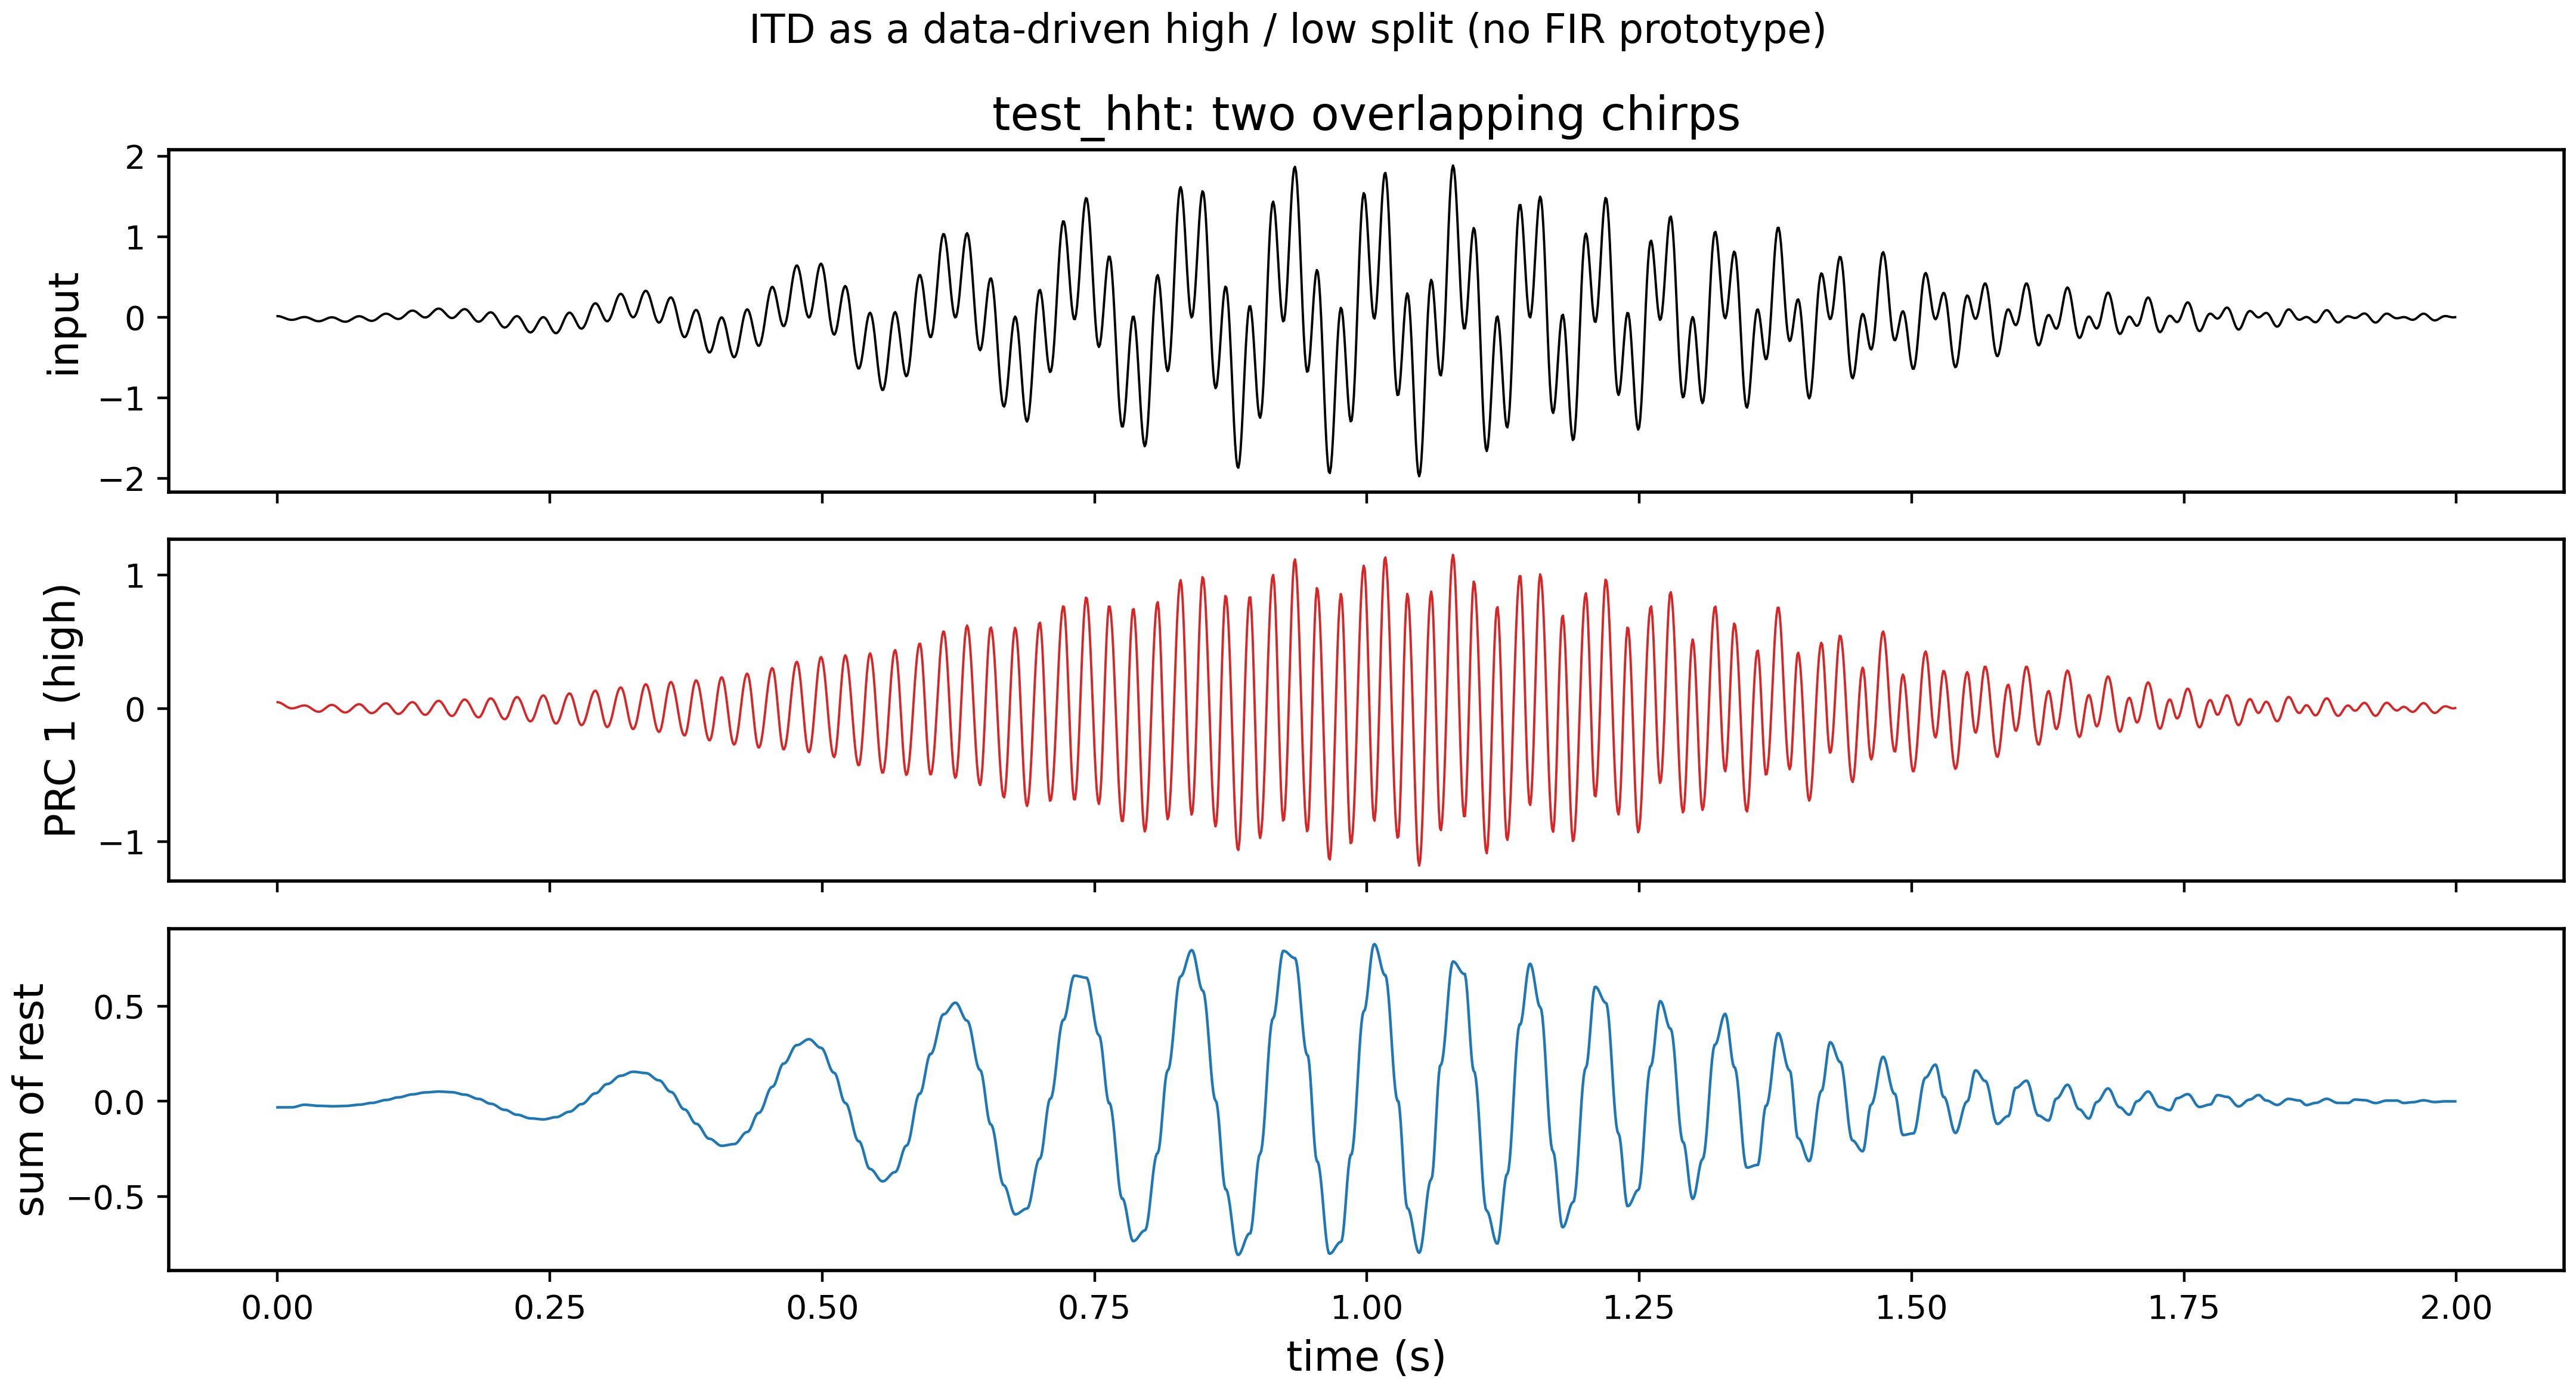

recon 2.220446049250313e-16


In [6]:
t3, x3 = test_hht()
prcs3 = ITD(N_max=8).fit_transform(x3)
x_lp = prcs3[1:].sum(axis=0)
x_hp = prcs3[0]

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
axes[0].plot(t3, x3, color="k", lw=0.7)
axes[0].set_ylabel("input")
axes[0].set_title("test_hht: two overlapping chirps")
axes[1].plot(t3, x_hp, color="C3", lw=0.7)
axes[1].set_ylabel("PRC 1 (high)")
axes[2].plot(t3, x_lp, color="C0", lw=0.8)
axes[2].set_ylabel("sum of rest")
axes[2].set_xlabel("time (s)")
fig.suptitle("ITD as a data-driven high / low split (no FIR prototype)")
plt.tight_layout()
plt.show()

print("recon", np.max(np.abs(prcs3.sum(0) - x3)))

## 7. Side-by-side with EMD

Same three-tone mixture, same number of extracted rows.  EMD sifts each
IMF until the envelopes are symmetric; ITD emits a PRC after **one**
baseline extract.  The first modes look similar; later rows differ
because the stop rules and the notion of “local mean” are not the same.


EMD (6, 1000) ITD (5, 1000)


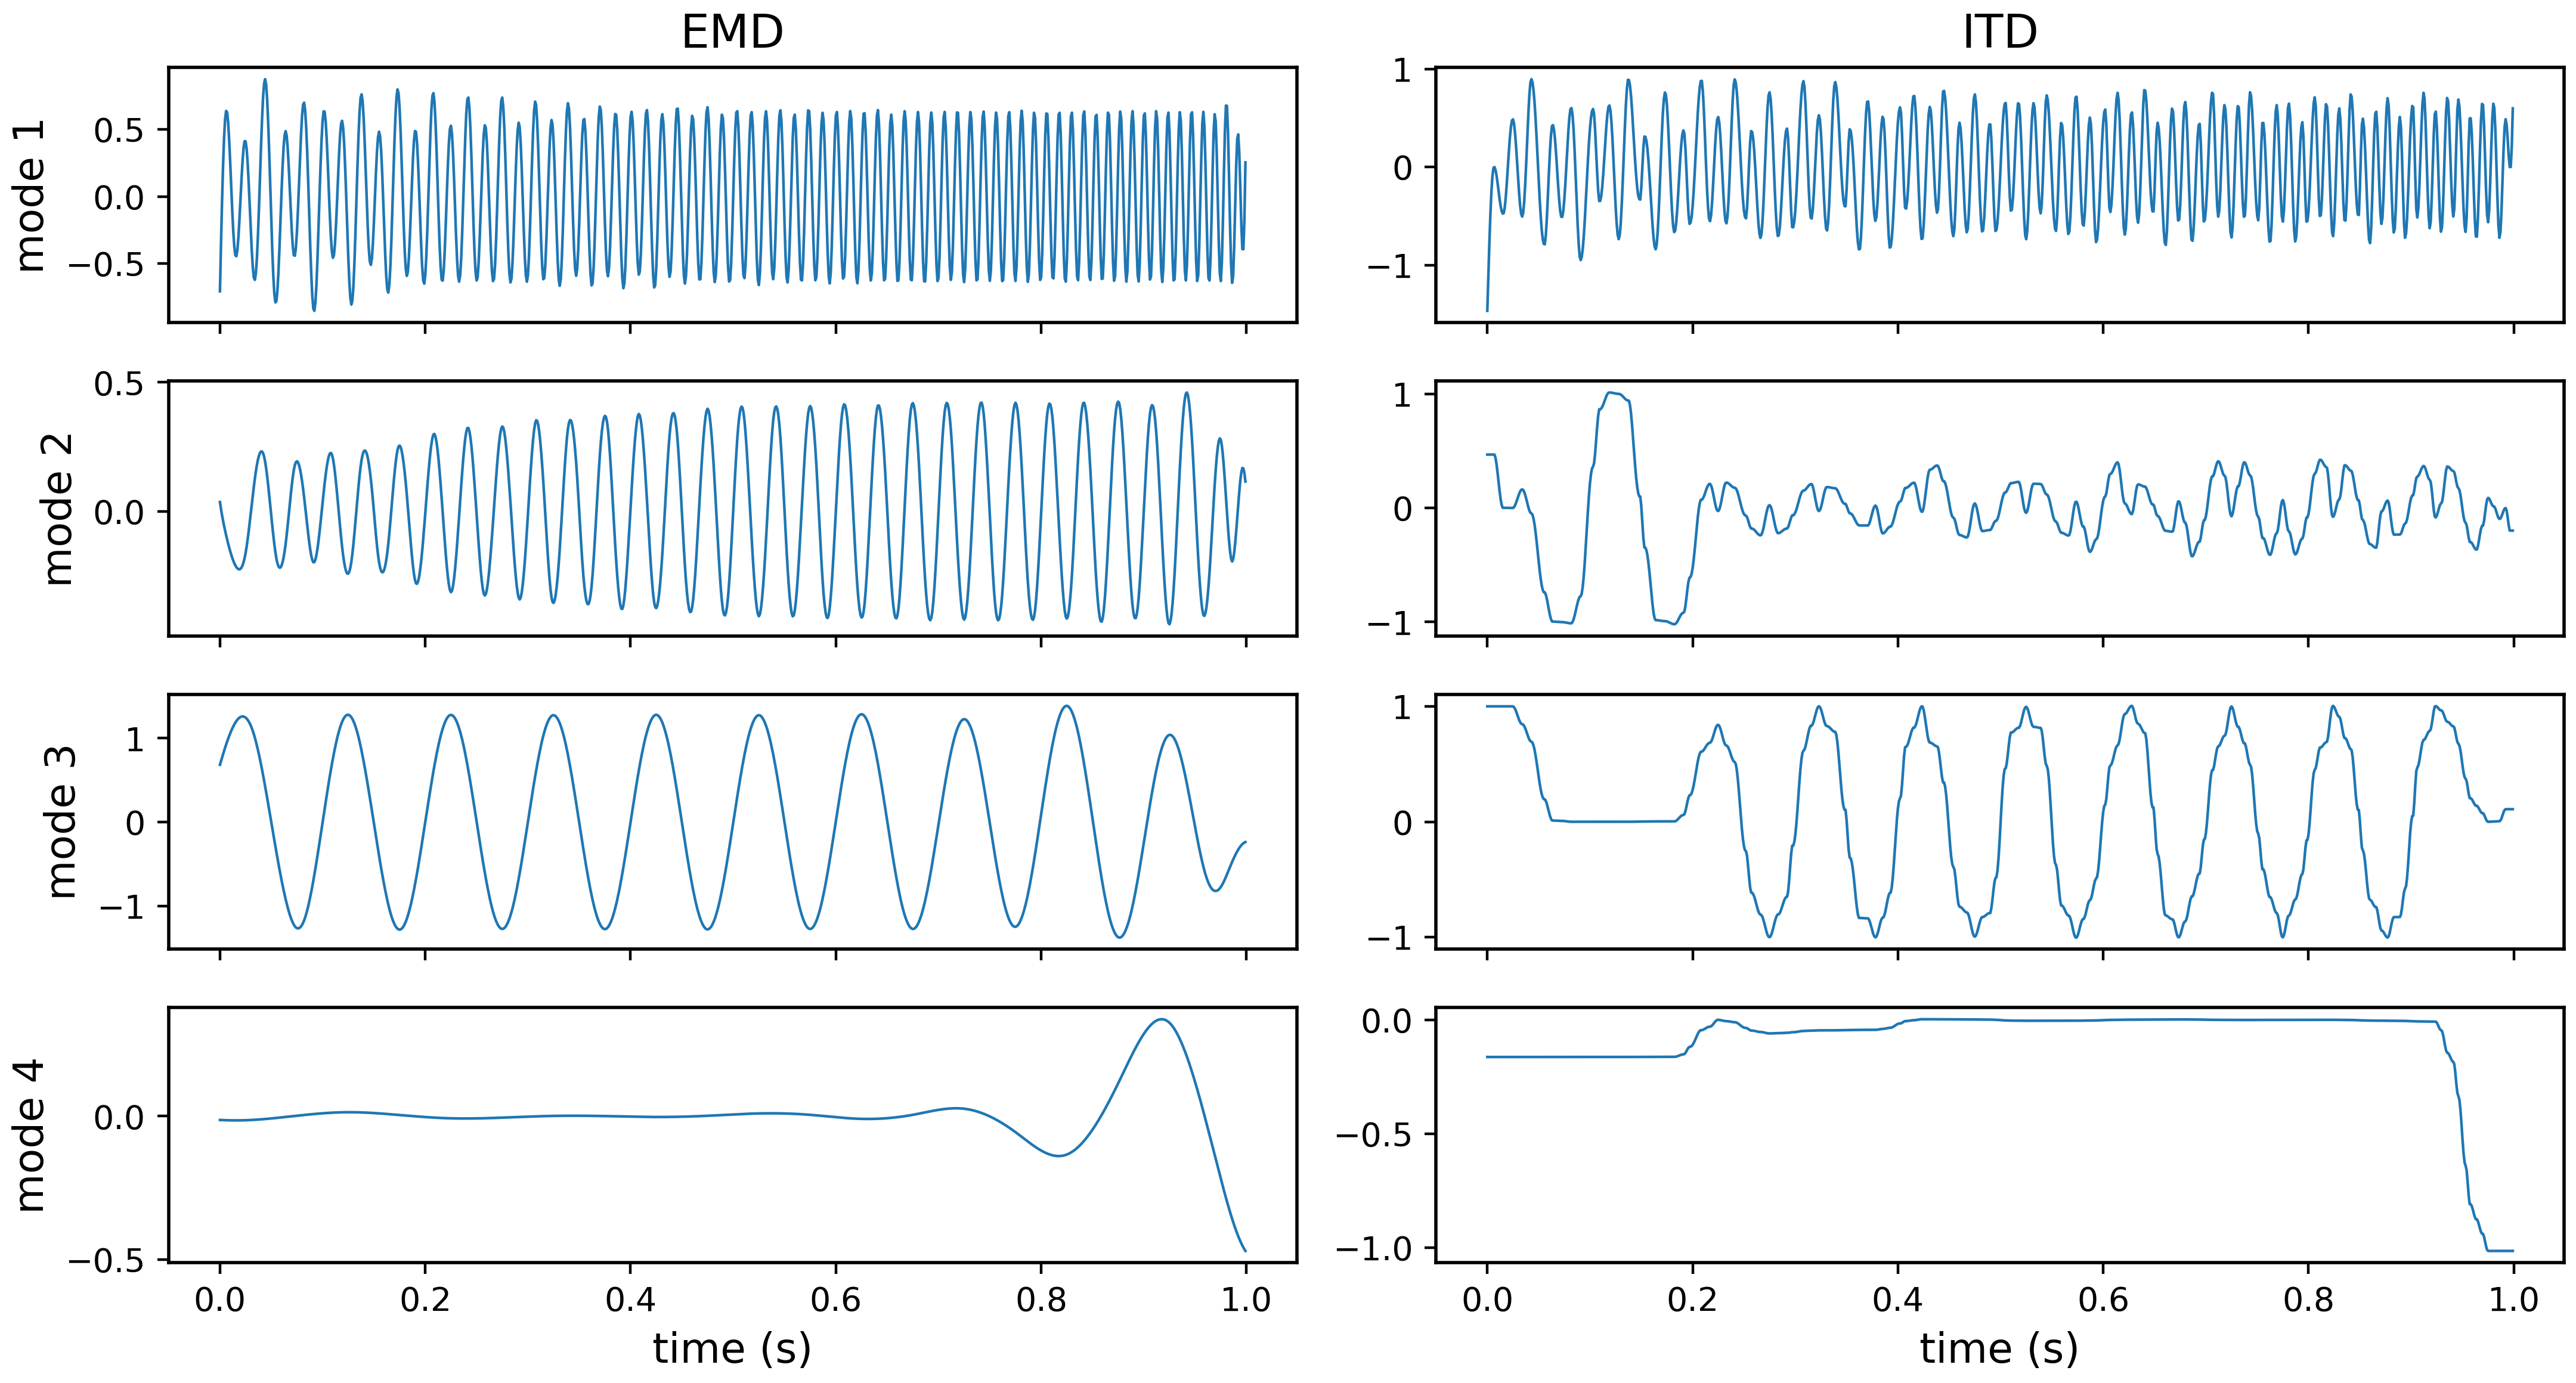

In [7]:
emd_imfs = EMD().fit_transform(signal)
print("EMD", emd_imfs.shape, "ITD", prcs.shape)

n_row = min(4, emd_imfs.shape[0], prcs.shape[0])
fig, axes = plt.subplots(n_row, 2, figsize=(11, 1.5 * n_row), sharex=True)
for k in range(n_row):
    axes[k, 0].plot(t, emd_imfs[k], lw=0.8)
    axes[k, 1].plot(t, prcs[k], lw=0.8)
    if k == 0:
        axes[k, 0].set_title("EMD")
        axes[k, 1].set_title("ITD")
    axes[k, 0].set_ylabel(f"mode {k + 1}")
axes[-1, 0].set_xlabel("time (s)")
axes[-1, 1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

## 8. Practical notes

- **Input:** 1-D `ndarray`.  Output shape `(n_prc + 1, n_samples)`; last
  row is the residue.  `ITD(N_max=10)(x)` is equivalent to
  `fit_transform`.
- **`N_max`:** hard cap on PRC count (MATLAB `N_max=10`).  Energy and
  extrema tests usually stop earlier.
- **Near-monotonic records:** if a side has no peaks, the baseline extract
  returns $(L,H)=(x,0)$ so the loop does not crash (see `test_itd.py`).
- **Related methods in PySDKit:** EMD / LMD (other extrema-based peels),
  HVD (amplitude-ordered Hilbert demodulation), ALIF (iterative filtering).
